# Imports (Run this first)

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dropout, Bidirectional, LSTM, Dense, Concatenate, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.utils import class_weight
import math
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Load datasets

In [3]:
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')
dataset_df = pd.read_json("complete_df.json", orient="records", lines=True)

file_path = './data_here/sample reports/sub_sample_reports_L1_input.txt'
additional_file_path = './data_here/sample reports/sub_sample_reports_L2_input.txt'

large_results_df = pd.read_csv(file_path, sep='\t')
L2_input_df = pd.read_csv(additional_file_path, sep='\t')
large_results_df = pd.concat([large_results_df, L2_input_df], ignore_index=True)
pd.set_option('display.max_columns', None)
small_results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

# Helper functions

In [7]:
def get_trial_coords(subitem, df):
    filtered_df = df[df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

def get_activity_centroids(item, df):
    item_df = df[df['item'] == item]
    
    a_item_df = item_df[item_df['IntAr'] == 'agent']
    x_mean = pd.to_numeric(a_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(a_item_df['Y_coord'], errors='coerce').mean()
    a_centroid = (x_mean, y_mean)
    
    b_item_df = item_df[item_df['IntAr'] == 'patient']
    x_mean = pd.to_numeric(b_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(b_item_df['Y_coord'], errors='coerce').mean()
    b_centroid = (x_mean, y_mean)

    return a_centroid, b_centroid

def get_dataset(df):
    complete_df = pd.DataFrame(columns=['subitem', 'item', 'participent_language', 'x_coords', 'y_coords', 'test_accuracy', 'a_dists', 'b_dists'])
    for subitem in df['subitem'].unique():
        a_dists = []
        b_dists = []
        
        item = df.loc[df['subitem'] == subitem, 'item'].unique()[0]
        x_coords, y_coords = get_trial_coords(subitem, df)
        
        a_centroid, b_centroid = get_activity_centroids(item, df)
        for i in range(len(x_coords)):
            a_dists.append(math.dist((x_coords[i], y_coords[i]), a_centroid))
            b_dists.append(math.dist((x_coords[i], y_coords[i]), b_centroid)) 
        
        participent_language = df.loc[df['subitem'] == subitem, 'participant_language'].unique()[0]
        test_accuracy = False if df[df['subitem'] == subitem]['memory_accuracy'].unique()[0] == "incorrect_response" else True

        complete_df.loc[len(complete_df)] = [subitem, item, participent_language, x_coords, y_coords, test_accuracy, a_dists, b_dists]
        
        print(subitem)
        clear_output(wait=True)
        
    return complete_df

def safe_parse_array(arr):
    if isinstance(arr, str):
        arr = eval(arr)
    return arr

# Generate large dataset features

In [225]:
def get_trial_coords(sub, item):
    filtered_df = large_results_df[large_results_df['RECORDING_SESSION_LABEL'] == sub]
    filtered_df = filtered_df[filtered_df['order_at_study'] == item]
    x_plots = filtered_df['AVERAGE_GAZE_X'].replace('.', None).astype(float).tolist()
    y_plots = filtered_df['AVERAGE_GAZE_Y'].replace('.', None).astype(float).tolist()
    return x_plots, y_plots

def get_activity_centroids(item):
    item_df = large_results_df[large_results_df['order_at_study'] == item]
    
    a_item_df = item_df[item_df['AVERAGE_INTEREST_AREA_ID'] == '1']
    x_mean = pd.to_numeric(a_item_df['AVERAGE_GAZE_X'], errors='coerce').mean()
    y_mean = pd.to_numeric(a_item_df['AVERAGE_GAZE_Y'], errors='coerce').mean()
    a_centroid = (x_mean, y_mean)
    
    b_item_df = item_df[item_df['AVERAGE_INTEREST_AREA_ID'] == '2']
    x_mean = pd.to_numeric(b_item_df['AVERAGE_GAZE_X'], errors='coerce').mean()
    y_mean = pd.to_numeric(b_item_df['AVERAGE_GAZE_Y'], errors='coerce').mean()
    b_centroid = (x_mean, y_mean)

    return a_centroid, b_centroid

def get_subitem_data(subitem, sub, item):
    x_coords, y_coords = get_trial_coords(sub, item)
    small_filtered_df = results_df[results_df['subitem'] == subitem]

    test_accuracy = False if small_filtered_df['memory_accuracy'].unique()[0] == "incorrect_response" else True
        
    return x_coords, y_coords, test_accuracy


def gen_training_dataframe():
    large_filtered_df = large_results_df[large_results_df['order_at_study'] != 0]
    
    # Precompute centroids
    centroids = {
        item: get_activity_centroids(item)
        for item in large_filtered_df['order_at_study'].unique()
    }

    # Pre-index data for fast access
    dataset_dict = dataset_df.set_index('subitem').to_dict(orient='index')
    language_dict = small_results_df.set_index('subitem')['participant_language'].to_dict()

    rows = []

    for sub in large_filtered_df['RECORDING_SESSION_LABEL'].unique():
        large_sub_filtered_df = large_filtered_df[large_filtered_df['RECORDING_SESSION_LABEL'] == sub]

        for item in large_sub_filtered_df['order_at_study'].unique():
            trial = f"{sub}_{item}"
            if trial not in dataset_dict or trial not in language_dict:
                continue

            row_data = dataset_dict[trial]
            x, y, test_accuracy = get_subitem_data(trial, sub, item)

            if len(x) == 0 or len(y) == 0:
                continue

            xy = np.column_stack((x, y))
            a_dists = np.linalg.norm(xy - centroids[item][0], axis=1).tolist()
            b_dists = np.linalg.norm(xy - centroids[item][1], axis=1).tolist()

            row = [
                trial, item, language_dict[trial], x, y, a_dists, b_dists, test_accuracy,
                row_data['semantic_relationship'], row_data['area_order'], row_data['gaze_shift'], row_data['distractions'],
                row_data['TA_strict_a'], row_data['TA_strict_b'], row_data['TA_loose_a'], row_data['TA_loose_b'],
                row_data['duration_agent'], row_data['duration_patient'], row_data['duration_empty'],
                row_data['agent_react_time'], row_data['patient_react_time'], row_data['agent_leave_time'], row_data['patient_leave_time'],
                row_data['agent_focus_on_onset'], row_data['patient_focus_on_onset']
            ]
            rows.append(row)
            clear_output(wait=True)
            print(pd.Series(row, index=[
                'subitem', 'item', 'participent_language', 'x_coords', 'y_coords', 'a_dists', 'b_dists', 
                'test_accuracy', 'semantic_relationship', 'area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 
                'TA_strict_b', 'TA_loose_a', 'TA_loose_b', 'duration_agent', 'duration_patient', 'duration_empty', 
                'agent_react_time', 'patient_react_time', 'agent_leave_time', 'patient_leave_time', 
                'agent_focus_on_onset', 'patient_focus_on_onset'
            ]))

    # Create final dataframe in one go
    complete_df = pd.DataFrame(rows, columns=[
        'subitem', 'item', 'participent_language', 'x_coords', 'y_coords', 'a_dists', 'b_dists', 
        'test_accuracy', 'semantic_relationship', 'area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 
        'TA_strict_b', 'TA_loose_a', 'TA_loose_b', 'duration_agent', 'duration_patient', 'duration_empty', 
        'agent_react_time', 'patient_react_time', 'agent_leave_time', 'patient_leave_time', 
        'agent_focus_on_onset', 'patient_focus_on_onset'
    ])
    
    return complete_df

large_complete_df = gen_training_dataframe()
large_complete_df.to_json("large_complete_df.json", orient="records", lines=True)

## Deep learning models (modify for dependant variable)

### Data pre-processing

In [8]:
# Load and parse data
sequence_length = 350
sequence_cols = ['x_coords', 'y_coords', 'a_dists', 'b_dists']
static_columns = [
    'test_accuracy', 'semantic_relationship', 'area_order', 'gaze_shift', 'distractions',
    'TA_strict_a', 'TA_strict_b', 'TA_loose_a', 'TA_loose_b',
    'duration_agent', 'duration_patient', 'duration_empty',
    'agent_react_time', 'patient_react_time',
    'agent_leave_time', 'patient_leave_time',
    'agent_focus_on_onset', 'patient_focus_on_onset'
]

for col in sequence_cols:
    dataset_df[col] = dataset_df[col].apply(safe_parse_array)

valid_rows = dataset_df.apply(
    lambda row: all(pd.notna(row[col]).any() for col in sequence_cols),
    axis=1
)
dataset_df = dataset_df[valid_rows].copy()

#Uncomment for relevant preprocessing
# Convert BILINGUAL to L1_participant for binary classification
#dataset_df['participent_language'] = dataset_df['participent_language'].apply(
#    lambda x: x[0] if isinstance(x, (np.ndarray, list)) else x
#)
#dataset_df['participent_language'] = dataset_df['participent_language'].replace('BILINGUAL', 'L1_participant')

# Drop BILINGUALs
#dataset_df = dataset_df[dataset_df['participent_language'] != 'BILINGUAL']

sequences = []
labels = []

for _, row in dataset_df.iterrows():
    x = np.array(row['x_coords'], dtype=np.float32)
    y = np.array(row['y_coords'], dtype=np.float32)
    a = np.array(row['a_dists'], dtype=np.float32)
    b = np.array(row['b_dists'], dtype=np.float32)

    valid_mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(a) & ~np.isnan(b)
    if not np.any(valid_mask): continue

    x, y, a, b = x[valid_mask], y[valid_mask], a[valid_mask], b[valid_mask]

    def norm(arr): return (arr - np.mean(arr)) / np.std(arr) if np.std(arr) > 0 else arr - np.mean(arr)
    features = np.stack([norm(x), norm(y), norm(a), norm(b)], axis=-1)

    #Uncomment for relevant Preprocessing

    # Take middle slice if longer than sequence_length
    if features.shape[0] > sequence_length:
        # Middle
        #start = (features.shape[0] - sequence_length) // 2
        #features = features[start:start + sequence_length]
        # End
        #features = features[-sequence_length:]
        # Spread
        indices = np.linspace(0, features.shape[0] - 1, sequence_length).astype(int)
        features = features[indices]
    
    sequences.append(features)
    labels.append(1 if row['participent_language'] == 'L2_participant' else 0)

X_seq = pad_sequences(sequences, maxlen=sequence_length, dtype='float32', padding='post', truncating='post')
y = np.array(labels, dtype=np.int32)

# Static feature processing
categorical_cols = []
numeric_cols = [col for col in static_columns if col not in categorical_cols]

dataset_df[numeric_cols] = dataset_df[numeric_cols].fillna(0)
dataset_df[categorical_cols] = dataset_df[categorical_cols].fillna('missing')

for col in numeric_cols:
    if dataset_df[col].dtype == 'bool':
        dataset_df[col] = dataset_df[col].astype(int)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_features = ohe.fit_transform(dataset_df[categorical_cols])

scaler = StandardScaler()
numeric_features = scaler.fit_transform(dataset_df[numeric_cols])

X_static = np.hstack([categorical_features, numeric_features])

### Train-Test Split

In [9]:
# Convert to Series
label_series = pd.Series(y)
total_samples = len(label_series)

subitems = dataset_df['subitem'].reset_index(drop=True)

# Determine test size
test_total = int(0.2 * total_samples)
half_test = test_total // 2

# Filter out _B variants for the test set
class0_idx = [i for i in label_series[label_series == 0].index if not subitems[i].endswith('_B')]
class1_idx = [i for i in label_series[label_series == 1].index if not subitems[i].endswith('_B')]

# Make sure there's enough data
half_test = min(half_test, len(class0_idx), len(class1_idx))

# Sample test indices
test_idx_0 = resample(class0_idx, n_samples=half_test, replace=False, random_state=42)
test_idx_1 = resample(class1_idx, n_samples=half_test, replace=False, random_state=42)
test_indices = np.concatenate([test_idx_0, test_idx_1])

# Compute test base names (strip _B if it's there)
test_base_names = set(
    subitems[i].replace('_B', '') for i in test_indices
)

# Filter out any train samples that match test base name or are their _B variants
train_indices = [
    i for i in label_series.index
    if i not in test_indices and subitems[i].replace('_B', '') not in test_base_names
]

# Sanity checks
print("Train samples:", len(train_indices))
print("Test samples:", len(test_indices))

# Slice arrays
X_seq_train = X_seq[train_indices]
X_seq_test = X_seq[test_indices]
X_static_train = X_static[train_indices]
X_static_test = X_static[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]



Train samples: 3472
Test samples: 868


## Transformer

In [11]:

# Positional Encoding Function
def positional_encoding(length, depth):
    depth = depth // 2
    positions = np.arange(length)[:, np.newaxis]  # (seq, 1)
    depths = np.arange(depth)[np.newaxis, :] / depth  # (1, depth)
    angle_rates = 1 / (10000**depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

# Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))

# Model Definition
sequence_input = Input(shape=(sequence_length, 4), name='sequence_input')
static_input = Input(shape=(X_static.shape[1],), name='static_input')

embedding_size = 64
x = Dense(embedding_size)(sequence_input)
pos_encoding = positional_encoding(sequence_length, embedding_size)
x = x + pos_encoding

x = TransformerBlock(embed_dim=embedding_size, num_heads=4, ff_dim=128)(x)
x = Dropout(0.2)(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)

s = Dense(64, activation='relu')(static_input)
s = Dropout(0.3)(s)

combined = Concatenate()([x, s])
combined = Dense(64, activation='relu')(combined)
combined = Dropout(0.3)(combined)
output = Dense(1, activation='sigmoid')(combined)

model = Model(inputs=[sequence_input, static_input], outputs=output)
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model.fit(
    [X_seq_train, X_static_train],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

y_pred_probs = model.predict([X_seq_test, X_static_test]).flatten()
y_pred = (y_pred_probs > 0.51).astype(int)
print(classification_report(y_test, y_pred, zero_division=0))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.4771 - loss: 0.7460 - val_accuracy: 0.4633 - val_loss: 0.7068
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 212ms/step - accuracy: 0.5338 - loss: 0.6976 - val_accuracy: 0.5640 - val_loss: 0.6888
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.5274 - loss: 0.6916 - val_accuracy: 0.5151 - val_loss: 0.6928
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.5737 - loss: 0.6864 - val_accuracy: 0.4719 - val_loss: 0.6971
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 219ms/step - accuracy: 0.5410 - loss: 0.6898 - val_accuracy: 0.4633 - val_loss: 0.6993
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 209ms/step - accuracy: 0.5522 - loss: 0.6881 - val_accuracy: 0.4633 - val_loss: 0.6977
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 210ms/step - accuracy: 0.5449 - loss: 0.6908 - val_accuracy: 0.4619 - val_loss: 0.7049
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step - accuracy: 0.5547 - loss: 0.6873 - val_accu

## LSTM

In [14]:
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Model definition
sequence_input = Input(shape=(sequence_length, 4), name='sequence_input')
static_input = Input(shape=(X_static.shape[1],), name='static_input')

#Comment out and uncomment relevant layers
x = Conv1D(64, kernel_size=5, activation='relu')(sequence_input)
x = Dropout(0.2)(x)
#x = Conv1D(64, kernel_size=3, activation='relu')(x)
#x = Dropout(0.2)(x)
#x = Bidirectional(LSTM(64, return_sequences=True))(x)
#x = Dropout(0.2)(x)
x = Bidirectional(LSTM(32))(x)
x = Dropout(0.2)(x)

s = Dense(64, activation='relu')(static_input)
s = Dropout(0.3)(s)

combined = Concatenate()([x, s])
combined = Dense(64, activation='relu')(combined)
combined = Dropout(0.3)(combined)
output = Dense(1, activation='sigmoid')(combined)

model = Model(inputs=[sequence_input, static_input], outputs=output)

In [15]:
for i in range(3):
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    # Train
    history = model.fit(
        [X_seq_train, X_static_train],
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Evaluate
    y_pred_probs = model.predict([X_seq_test, X_static_test]).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)
    
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5228 - loss: 0.7251 - val_accuracy: 0.4547 - val_loss: 0.7058
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.5524 - loss: 0.6882 - val_accuracy: 0.4604 - val_loss: 0.7042
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.5506 - loss: 0.6871 - val_accuracy: 0.4835 - val_loss: 0.7045
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.5505 - loss: 0.6903 - val_accuracy: 0.4748 - val_loss: 0.7106
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.5715 - loss: 0.6825 - val_accuracy: 0.4993 - val_loss: 0.6991
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.5814 - loss: 0.6789 - val_accuracy: 0.4993 - val_loss: 0.7022
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.5437 - loss: 0.6831 - val_accuracy: 0.4849 - val_loss: 0.7076
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.5647 - loss: 0.6757 - val_accuracy: 0.48

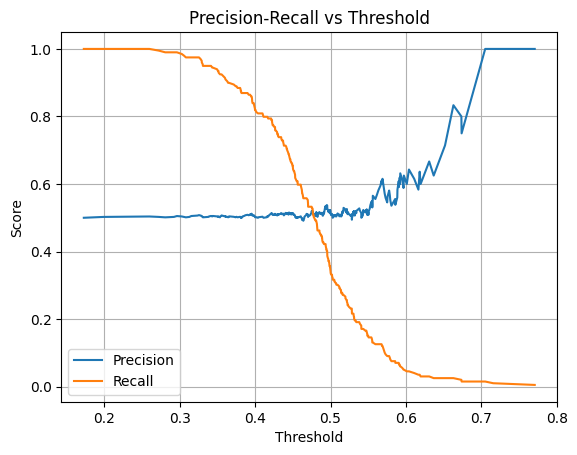

In [553]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Regression Models

## Agent React Time Linear Regression

In [833]:

# Load and filter dataset
dataset_df = pd.read_json("complete_df.json", orient="records", lines=True)
dataset_df = dataset_df.dropna(subset=['agent_react_time'])

# Target variable
y = dataset_df['agent_react_time'].astype(float)

# Feature selection
X = dataset_df[[
    'area_order', 'gaze_shift', 'distractions', 'semantic_relationship',
    'test_accuracy', 'participent_language'
]]

# One-hot encode the categorical variable
X = pd.get_dummies(X, columns=['participent_language'], drop_first=True)

X['test_accuracy'] = X['test_accuracy'].astype(int)
X = X.astype({col: int for col in X.select_dtypes(bool).columns})

# Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# VIF (Multicollinearity check)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])
]
print("\nVariance Inflation Factors (VIF):\n", vif_data)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Add constant (intercept) to features
X_train_scaled_const = sm.add_constant(X_train_scaled)
X_test_scaled_const = sm.add_constant(X_test_scaled)

# Fit OLS regression model
lin_reg = sm.OLS(y_train, X_train_scaled_const).fit()
print("\nLinear Regression Summary:\n", lin_reg.summary())

# Predict and evaluate
y_pred = lin_reg.predict(X_test_scaled_const)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared: {r2:.4f}")

coefs = lin_reg.params
equation = f"y = {coefs['const']:.3f} " + " + ".join([
    f"{coef:.3f}·{name}" for name, coef in coefs.items() if name != 'const'
])
print("Linear Regression Equation:\n", equation)


Variance Inflation Factors (VIF):
                                Feature       VIF
0                           area_order  6.241224
1                           gaze_shift  7.440189
2                         distractions  1.232637
3                semantic_relationship  2.125543
4                        test_accuracy  3.305077
5  participent_language_L1_participant  2.628369
6  participent_language_L2_participant  3.161880

Linear Regression Summary:
                             OLS Regression Results                            
Dep. Variable:       agent_react_time   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     18.58
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           1.89e-24
Time:                        20:22:49   Log-Likelihood:                -26716.
No. Observations:                3432   AIC:                         

## Agent Leave Time Linear Regression

In [808]:
# Load and filter dataset
dataset_df = pd.read_json("complete_df.json", orient="records", lines=True)
dataset_df = dataset_df.dropna(subset=['agent_leave_time'])

# Target variable
y = dataset_df['agent_leave_time'].astype(float)

# Feature selection
X = dataset_df[[
    'area_order', 'gaze_shift', 'distractions', 'semantic_relationship',
    'test_accuracy', 'participent_language'
]]

# One-hot encode the categorical variable
X = pd.get_dummies(X, columns=['participent_language'], drop_first=True)

X['test_accuracy'] = X['test_accuracy'].astype(int)
X = X.astype({col: int for col in X.select_dtypes(bool).columns})

# Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# VIF (Multicollinearity check)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])
]
print("\nVariance Inflation Factors (VIF):\n", vif_data)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Add constant (intercept) to features
X_train_scaled_const = sm.add_constant(X_train_scaled)
X_test_scaled_const = sm.add_constant(X_test_scaled)

# Fit OLS regression model
lin_reg = sm.OLS(y_train, X_train_scaled_const).fit()
print("\nLinear Regression Summary:\n", lin_reg.summary())

# Predict and evaluate
y_pred = lin_reg.predict(X_test_scaled_const)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared: {r2:.4f}")


Variance Inflation Factors (VIF):
                                Feature       VIF
0                           area_order  6.477861
1                           gaze_shift  7.828194
2                         distractions  1.233036
3                semantic_relationship  2.164861
4                        test_accuracy  3.412443
5  participent_language_L1_participant  2.635818
6  participent_language_L2_participant  3.191859

Linear Regression Summary:
                             OLS Regression Results                            
Dep. Variable:       agent_leave_time   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     44.66
Date:                Tue, 22 Apr 2025   Prob (F-statistic):           1.07e-60
Time:                        00:54:09   Log-Likelihood:                -26230.
No. Observations:                3288   AIC:                         

## Gaze order Logistic Regression

In [812]:
# Load and filter dataset
dataset_df = pd.read_json("complete_df.json", orient="records", lines=True)
dataset_df = dataset_df.dropna(subset=['ordered'])

# Select features and target
X = dataset_df[[
    'gaze_shift', 'distractions',
    'duration_agent', 'duration_empty', 'semantic_relationship',
    'agent_react_time', 'patient_react_time',
    'agent_leave_time', 'patient_leave_time',
    'agent_focus_on_onset', 'patient_focus_on_onset', 'test_accuracy'
]]
y = dataset_df['ordered'].astype(int)

# One-hot encode and numeric conversion
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert boolean-like columns to int
bool_cols = ['agent_focus_on_onset', 'patient_focus_on_onset', 'test_accuracy']
X[bool_cols] = X[bool_cols].astype(int)

# Balanced test set creation
total_samples = len(y)
test_size = int(0.2 * total_samples)

# Split indices by class
class_0_idx = y[y == 0].index
class_1_idx = y[y == 1].index

# Determine per-class size for test
per_class = min(len(class_0_idx), len(class_1_idx), test_size // 2)

# Sample test indices
test_idx_0 = resample(class_0_idx, n_samples=per_class, replace=False, random_state=42)
test_idx_1 = resample(class_1_idx, n_samples=per_class, replace=False, random_state=42)
test_indices = np.concatenate([test_idx_0, test_idx_1])

# Remaining for train
train_indices = y.drop(index=test_indices).index

# Create train/test splits
X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

# VIF check
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])
]
print("\nVariance Inflation Factors (VIF):\n", vif_data)

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Add intercept
X_train_scaled_const = sm.add_constant(X_train_scaled)
X_test_scaled_const = sm.add_constant(X_test_scaled)

# Fit logistic regression
log_reg = sm.Logit(y_train, X_train_scaled_const).fit()
print("\nLogistic Regression Summary:\n", log_reg.summary())

# Predict and evaluate
yhat_prob = log_reg.predict(X_test_scaled_const)
yhat = (yhat_prob >= 0.5).astype(int)

# Metrics
cm = confusion_matrix(y_test, yhat)
print("\nConfusion Matrix:\n", cm)
print(f"Test Accuracy: {accuracy_score(y_test, yhat) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, yhat, zero_division=0):.2f}")
print(f"Recall: {recall_score(y_test, yhat, zero_division=0):.2f}")
print(f"F1 Score: {f1_score(y_test, yhat, zero_division=0):.2f}")
print("\nClassification Report:\n", classification_report(y_test, yhat, zero_division=0))




Variance Inflation Factors (VIF):
                    Feature       VIF
0               gaze_shift  9.328423
1             distractions  1.657597
2           duration_agent  7.324091
3           duration_empty  5.554964
4    semantic_relationship  2.098169
5         agent_react_time  2.779471
6       patient_react_time  2.582952
7         agent_leave_time  4.647700
8       patient_leave_time  2.705633
9     agent_focus_on_onset  3.025140
10  patient_focus_on_onset  3.576484
11           test_accuracy  3.339233
Optimization terminated successfully.
         Current function value: 0.612433
         Iterations 5

Logistic Regression Summary:
                            Logit Regression Results                           
Dep. Variable:                ordered   No. Observations:                 3472
Model:                          Logit   Df Residuals:                     3459
Method:                           MLE   Df Model:                           12
Date:                Tue, 22 Apr 2

## Memory Logistic Regression

In [824]:


# Load data
complete_df = pd.read_json("complete_df.json", orient="records", lines=True)
complete_df = complete_df.dropna(subset=['test_accuracy'])

# Define features and target
X = complete_df[[
    'area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 'TA_loose_a', 'TA_loose_b', 'ordered', 
    'duration_agent', 'semantic_relationship', 'agent_react_time', 'patient_react_time', 
    'agent_leave_time', 'patient_leave_time', 'agent_focus_on_onset', 'patient_focus_on_onset'
]]
y = complete_df['test_accuracy'].astype(int)

# Encode categorical and boolean fields
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
bool_cols = ['TA_loose_a', 'TA_loose_b', 'ordered', 'agent_focus_on_onset', 'patient_focus_on_onset']
X[bool_cols] = X[bool_cols].astype(int)

# Balanced test set logic
total_samples = len(y)
test_size = int(0.2 * total_samples)

# Split indices by class
class_0_idx = y[y == 0].index
class_1_idx = y[y == 1].index

# Sample equally from both classes for test set
per_class = min(len(class_0_idx), len(class_1_idx), test_size // 2)
test_idx_0 = resample(class_0_idx, n_samples=per_class, replace=False, random_state=42)
test_idx_1 = resample(class_1_idx, n_samples=per_class, replace=False, random_state=42)
test_indices = np.concatenate([test_idx_0, test_idx_1])

# Remaining data is training set
train_indices = y.drop(index=test_indices).index

# Slice into train/test sets
X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factors (VIF):\n", vif_data)

# Fit logistic regression
log_reg = sm.Logit(y_train, X_train_scaled).fit()
print("\nLogistic Regression Summary:\n", log_reg.summary())

# Predict
yhat_prob = log_reg.predict(X_test_scaled)
yhat = (yhat_prob >= 0.5).astype(int)

# Evaluate
print("\nConfusion Matrix:\n", confusion_matrix(y_test, yhat))
print(f"Test Accuracy: {accuracy_score(y_test, yhat) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, yhat, zero_division=0):.2f}")
print(f"Recall: {recall_score(y_test, yhat, zero_division=0):.2f}")
print(f"F1 Score: {f1_score(y_test, yhat, zero_division=0):.2f}")
print("\nClassification Report:\n", classification_report(y_test, yhat, zero_division=0))



Variance Inflation Factors (VIF):
                    Feature        VIF
0               area_order  24.229300
1               gaze_shift  14.076053
2             distractions   1.298837
3              TA_strict_a   6.284620
4               TA_loose_a   9.965615
5               TA_loose_b  11.389399
6                  ordered   9.598026
7           duration_agent  10.111970
8    semantic_relationship   2.184999
9         agent_react_time   4.479962
10      patient_react_time   3.808424
11        agent_leave_time   5.559231
12      patient_leave_time   2.866305
13    agent_focus_on_onset   3.945544
14  patient_focus_on_onset   4.730366
Optimization terminated successfully.
         Current function value: 0.691519
         Iterations 4

Logistic Regression Summary:
                            Logit Regression Results                           
Dep. Variable:          test_accuracy   No. Observations:                 3472
Model:                          Logit   Df Residuals:            

## Semantic Similarity vs test accuracy

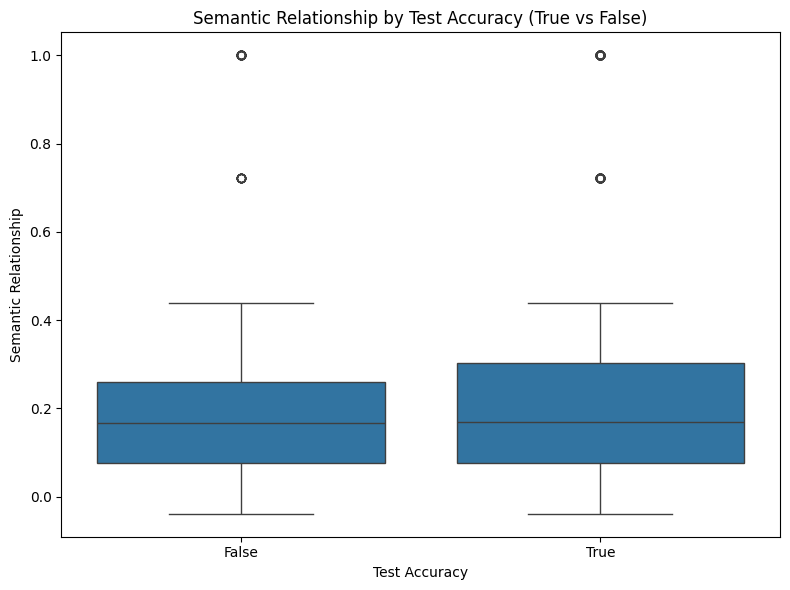

In [829]:
dataset_df = pd.read_json("complete_df.json", orient="records", lines=True)

dataset_df['test_accuracy'] = dataset_df['test_accuracy'].astype(bool)

plt.figure(figsize=(8, 6))
sns.boxplot(x='test_accuracy', y='semantic_relationship', data=dataset_df)

plt.xlabel('Test Accuracy')
plt.ylabel('Semantic Relationship')
plt.title('Semantic Relationship by Test Accuracy (True vs False)')
plt.xticks([0, 1], ['False', 'True'])

plt.tight_layout()
plt.show()
